# Detecting Data Drift with Distance Metrics

See [`docs/04-detecting-data-drift.md`](../docs/04-detecting-data-drift.md#distance-metrics) for the
concept notes this notebook is based on.

Instead of testing "are these the same distribution?", distance metrics quantify **how far apart**
two distributions are. The output is a continuous "drift size" you can track over time, rather than
a binary same/different verdict.

All four notebooks in this folder analyze the exact same synthetic `reference`/`current` pair from
[`src/drift_dataset.py`](../src/drift_dataset.py), so results are directly comparable across techniques.

## Load the shared reference/current dataset

In [1]:
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from src import (
    CATEGORICAL_COLUMNS,
    COLUMN_DRIFT_GROUND_TRUTH,
    NUMERICAL_COLUMNS,
    make_reference_and_current,
)

pd.set_option("display.width", 120)

reference, current = make_reference_and_current(seed=42)
print("reference:", reference.shape, " current:", current.shape)
reference.head()

reference: (5000, 6)  current: (2000, 6)


,channel,product_category,basket_size,discount_pct,unit_price,customer_age
0,in_store,electronics,21.102831,0.031317,17.104594,32.639729
1,in_store,grocery,63.178040,0.062780,22.418914,46.994313
2,online,home,51.468098,0.173390,15.736280,43.558738
3,in_store,electronics,46.992552,0.189024,16.649926,52.330196
4,in_store,electronics,53.157178,0.080097,18.866577,44.449209


## Wasserstein distance (numerical features)

The "earth mover's distance": the minimum amount of probability mass that has to move, and how far,
to turn one distribution into the other. It's on the same scale/units as the feature itself, so we
also report a standardized version (divided by the reference standard deviation) to compare features
with different units on one scale.

In [2]:
from scipy import stats

def wasserstein_table(ref, cur, columns):
    rows = []
    for col in columns:
        distance = stats.wasserstein_distance(ref[col], cur[col])
        rows.append({
            "feature": col,
            "wasserstein_distance": distance,
            "wasserstein_std_units": distance / ref[col].std(),
        })
    return pd.DataFrame(rows).set_index("feature").round(4)

wasserstein_result = wasserstein_table(reference, current, NUMERICAL_COLUMNS)
wasserstein_result

,wasserstein_distance,wasserstein_std_units
feature,,
basket_size,12.9148,0.8497
discount_pct,0.0197,0.3237
unit_price,0.4139,0.0462
customer_age,3.6925,0.3198


## Jensen-Shannon divergence (numerical and categorical)

A symmetric, bounded measure of how different two probability distributions are (0 = identical,
1 = maximally different, with `base=2`). For numerical features we bin both samples into a shared
histogram first; for categorical features we compare category-proportion vectors directly.

In [3]:
from scipy.spatial.distance import jensenshannon

def js_divergence_numeric(ref_vals, cur_vals, bins=20):
    lo = min(ref_vals.min(), cur_vals.min())
    hi = max(ref_vals.max(), cur_vals.max())
    edges = np.linspace(lo, hi, bins + 1)
    p, _ = np.histogram(ref_vals, bins=edges)
    q, _ = np.histogram(cur_vals, bins=edges)
    p = p / p.sum()
    q = q / q.sum()
    return jensenshannon(p, q, base=2)

def js_divergence_categorical(ref_series, cur_series):
    categories = sorted(set(ref_series) | set(cur_series))
    p = ref_series.value_counts(normalize=True).reindex(categories, fill_value=0).values
    q = cur_series.value_counts(normalize=True).reindex(categories, fill_value=0).values
    return jensenshannon(p, q, base=2)

js_rows = []
for col in NUMERICAL_COLUMNS:
    js_rows.append({"feature": col, "js_divergence": js_divergence_numeric(reference[col].values, current[col].values)})
for col in CATEGORICAL_COLUMNS:
    js_rows.append({"feature": col, "js_divergence": js_divergence_categorical(reference[col], current[col])})

js_result = pd.DataFrame(js_rows).set_index("feature").round(4)
js_result

,js_divergence
feature,
basket_size,0.2889
discount_pct,0.1482
unit_price,0.0500
customer_age,0.0420
channel,0.2802
product_category,0.2728


## Population Stability Index (PSI)

A distance metric from credit risk modeling, widely used with a conventional interpretation scale:
`< 0.1` no significant shift, `0.1-0.25` moderate shift, `> 0.25` significant shift. Numerical
features are binned into reference-derived deciles; categorical features use category proportions
directly.

In [4]:
def psi_interpretation(psi):
    if psi < 0.1:
        return "no significant shift"
    if psi < 0.25:
        return "moderate shift"
    return "significant shift"

def psi_numeric(ref_vals, cur_vals, bins=10):
    edges = np.quantile(ref_vals, np.linspace(0, 1, bins + 1))
    edges[0], edges[-1] = -np.inf, np.inf
    ref_counts, _ = np.histogram(ref_vals, bins=edges)
    cur_counts, _ = np.histogram(cur_vals, bins=edges)
    ref_pct = np.clip(ref_counts / ref_counts.sum(), 1e-4, None)
    cur_pct = np.clip(cur_counts / cur_counts.sum(), 1e-4, None)
    return float(np.sum((cur_pct - ref_pct) * np.log(cur_pct / ref_pct)))

def psi_categorical(ref_series, cur_series):
    categories = sorted(set(ref_series) | set(cur_series))
    ref_pct = ref_series.value_counts(normalize=True).reindex(categories, fill_value=0).clip(lower=1e-4)
    cur_pct = cur_series.value_counts(normalize=True).reindex(categories, fill_value=0).clip(lower=1e-4)
    ref_pct, cur_pct = ref_pct / ref_pct.sum(), cur_pct / cur_pct.sum()
    return float(np.sum((cur_pct - ref_pct) * np.log(cur_pct / ref_pct)))

psi_rows = []
for col in NUMERICAL_COLUMNS:
    psi_rows.append({"feature": col, "psi": psi_numeric(reference[col].values, current[col].values)})
for col in CATEGORICAL_COLUMNS:
    psi_rows.append({"feature": col, "psi": psi_categorical(reference[col], current[col])})

psi_result = pd.DataFrame(psi_rows).set_index("feature").round(4)
psi_result["interpretation"] = psi_result["psi"].apply(psi_interpretation)
psi_result

,psi,interpretation
feature,,
basket_size,0.4344,significant shift
discount_pct,0.1149,moderate shift
unit_price,0.0070,no significant shift
customer_age,0.0057,no significant shift
channel,0.4517,significant shift
product_category,1.0353,significant shift


## All three metrics side by side, plus an aggregate drift share

In [5]:
combined = wasserstein_result[["wasserstein_std_units"]].join(js_result).join(psi_result)
combined

,wasserstein_std_units,js_divergence,psi,interpretation
feature,,,,
basket_size,0.8497,0.2889,0.4344,significant shift
discount_pct,0.3237,0.1482,0.1149,moderate shift
unit_price,0.0462,0.0500,0.0070,no significant shift
customer_age,0.3198,0.0420,0.0057,no significant shift


In [6]:
drifted_share = (combined["psi"] >= 0.1).mean()
print(f"{(combined['psi'] >= 0.1).sum()} of {len(combined)} features show at least a moderate PSI shift "
      f"({drifted_share:.0%} of the dataset).")

2 of 4 features show at least a moderate PSI shift (50% of the dataset).


## Sample-size contrast: does the metric collapse to "significant" at scale like a p-value does?

Reusing the same two cases from `02_statistical_tests.ipynb` — `unit_price` (no real drift) and
`discount_pct` (a small real drift) — but tracking Wasserstein distance instead of a p-value.

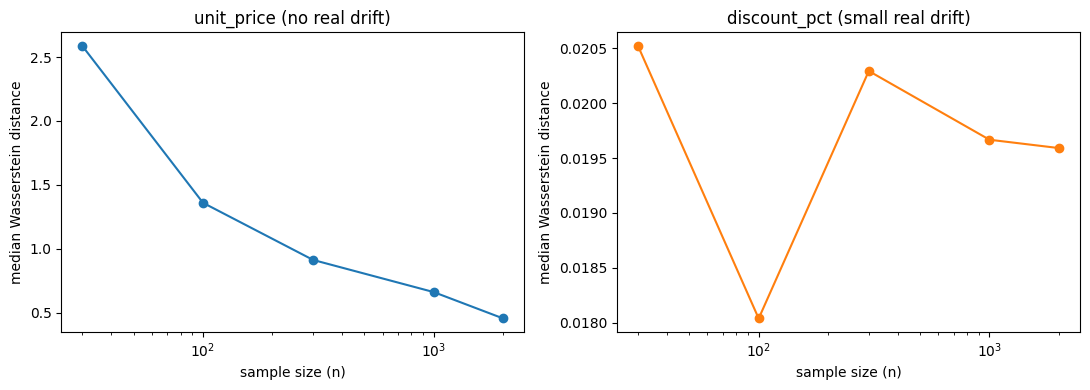

In [7]:
def subsample_distance_curve(a, b, sizes, repeats=30, seed=1):
    rng = np.random.default_rng(seed)
    a, b = np.asarray(a), np.asarray(b)
    rows = []
    for n in sizes:
        distances = []
        for _ in range(repeats):
            sample_a = rng.choice(a, size=min(n, len(a)), replace=False)
            sample_b = rng.choice(b, size=min(n, len(b)), replace=False)
            distances.append(stats.wasserstein_distance(sample_a, sample_b))
        rows.append({"n": n, "median_wasserstein": np.median(distances)})
    return pd.DataFrame(rows)

sizes = [30, 100, 300, 1000, 2000]
case_a = subsample_distance_curve(reference["unit_price"], current["unit_price"], sizes)
case_b = subsample_distance_curve(reference["discount_pct"], current["discount_pct"], sizes)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(case_a["n"], case_a["median_wasserstein"], marker="o", color="tab:blue")
axes[0].set_title("unit_price (no real drift)")
axes[1].plot(case_b["n"], case_b["median_wasserstein"], marker="o", color="tab:orange")
axes[1].set_title("discount_pct (small real drift)")
for ax in axes:
    ax.set_xscale("log")
    ax.set_xlabel("sample size (n)")
    ax.set_ylabel("median Wasserstein distance")
fig.tight_layout()
plt.show()

Unlike the KS p-value in notebook 02, the Wasserstein distance for each case stays roughly **flat**
across sample sizes — it estimates the same underlying gap whether measured from 30 rows or 2000.
That's the practical case for preferring distance metrics on large production batches: the score
doesn't artificially "become significant" just because you fed it more data.

## When to use distance metrics

- Best for **large datasets**, where statistical tests tend to become overly sensitive (see the
  contrast above).
- Gives a **magnitude**, not just a verdict — useful for tracking "how much has this drifted" as a
  trend over time, or ranking features by how much they've shifted.
- PSI's conventional thresholds (`0.1` / `0.25`) give a quick severity read without needing a
  p-value's statistical framing; it's an industry-standard choice in credit risk modeling for
  exactly this reason.
- Can be aggregated into a single "share of drifted features" summary, which is often a better
  top-level alerting signal than watching every feature's raw score individually.

## Answer key

What this synthetic scenario was built to demonstrate for each column:

In [8]:
pd.Series(COLUMN_DRIFT_GROUND_TRUTH, name="ground_truth").to_frame()

,ground_truth
channel,drift
product_category,drift
basket_size,drift
discount_pct,borderline
unit_price,none
customer_age,data_quality
